# Cuatro transformers sobre un mismo texto
## Resumen, entidades, preguntas y similitud sobre un capítulo de novela

**Autor:** Jheison Martinez Bolivar
**Maestría:** Inteligencia Artificial
**Fecha:** septiembre 2026
**Texto:** un capítulo de novela, en texto plano

---

### Planteamiento del Proyecto

La actividad pide resolver cuatro problemas distintos de NLP con modelos Transformer del Hub de Hugging Face, usando la librería `transformers`, y sin repetir tarea ni reutilizar los modelos vistos en clase (análisis de sentimiento, clasificación de texto, *fill-mask* y generación con GPT-2).

En vez de cuatro demostraciones sueltas sobre frases inventadas, quiero que los cuatro modelos trabajen sobre el mismo texto y que cada uno le haga una pregunta al anterior. El texto base es un capítulo de novela: prosa literaria, con personajes y lugares con nombre, que es lo contrario del tipo de texto (noticias) con que se entrenan casi todos estos modelos. Esa distancia es parte de lo que quiero medir.

Las tareas, el libro y su encadenamiento se fijan después de mirar el texto y los modelos disponibles: primero hay que saber cuánto mide un capítulo, cómo está partido y qué cabe dentro de la ventana de entrada de los modelos que existen.


In [1]:
%pip install -q "transformers<5" "sentence-transformers<6" span_marker sacremoses sentencepiece

Note: you may need to restart the kernel to use updated packages.


### Intento 1: *Cien años de soledad*, capítulo I

Arranco con el primer capítulo de *Cien años de soledad* (Gabriel García Márquez, 1967): la llegada de los gitanos a Macondo, el imán, la lupa, el hielo. Lo extraje de una edición en PDF con `extraer_capitulo.py`, que separa los párrafos por la sangría del original y quita los encabezados de página; en el notebook solo entra ese capítulo, no la novela. Los capítulos extraídos viajan como archivos de texto en `data/` junto al notebook; en Colab hay que subirlos antes de ejecutar.

Lo elegí porque está en español, que es donde el Hub tiene menos modelos y donde más interesa saber qué tan bien funcionan, y porque es prosa literaria de alta calidad con muchos personajes y lugares nombrados.


In [2]:
import os
os.environ['HF_HUB_DISABLE_PROGRESS_BARS'] = '1'

from pathlib import Path
import pandas as pd
import transformers

transformers.logging.set_verbosity_error()
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', 70)

text = Path('data/capitulo_01.txt').read_text(encoding='utf-8')
paragraphs = [p for p in text.split('\n\n') if p.strip()]

paragraph_table = pd.DataFrame({
    'words': [len(p.split()) for p in paragraphs],
    'chars': [len(p) for p in paragraphs],
    'start': [p[:60] + '…' for p in paragraphs],
})
print(f'{len(paragraphs)} párrafos, {paragraph_table.words.sum()} palabras, {paragraph_table.chars.sum()} caracteres')
paragraph_table.words.describe().round(1)


36 párrafos, 5876 palabras, 34767 caracteres


count     36.0
mean     163.2
std      180.4
min        6.0
25%       14.0
50%      117.0
75%      270.2
max      810.0
Name: words, dtype: float64

In [3]:
paragraph_table


,words,chars,start
0,479,2850,"Muchos años después, frente al pelotón de fusilamiento, el c…"
1,810,4760,En marzo volvieron los gitanos. Esta vez llevaban un catalej…
2,7,39,-La tierra es redonda como una naranja.…
3,166,1001,"Úrsula perdió la paciencia. «Si has de volverte loco, vuélve…"
4,413,2527,"Para esa época, Melquíades había envejecido con una rapidez …"
5,7,35,-Es el olor del demonio -dijo ella.…
6,22,137,-En absoluto -corrigió Melquíades-. Está comprobado que el d…
7,40,249,"Siempre didáctico, hizo una sabia exposición sobre las virtu…"
8,265,1674,El rudimentario laboratorio -sin contar una profusión de caz…
9,308,1871,"Cuando volvieron los gitanos, Úrsula había predispuesto cont…"


Contar palabras es una aproximación: los modelos ven *tokens*, y cada modelo trae su propio tokenizador. Para resumir en español el modelo con más uso y mejor documentado del Hub es `csebuetnlp/mT5_multilingual_XLSum` (mT5, SentencePiece multilingüe, 45 idiomas, entrada de **512 tokens**). Antes de decidir cómo trocear, mido cuántos tokens produce su tokenizador sobre cada párrafo y cuántos párrafos exceden el límite.


In [4]:
from transformers import AutoTokenizer

SUMMARIZER_ID = 'csebuetnlp/mT5_multilingual_XLSum'
MAX_TOKENS = 512
tokenizer = AutoTokenizer.from_pretrained(SUMMARIZER_ID)

def count_tokens(s):
    return len(tokenizer(s, add_special_tokens=False)['input_ids'])

paragraph_table['tokens'] = [count_tokens(p) for p in paragraphs]
paragraph_table['fits'] = paragraph_table.tokens + 1 <= MAX_TOKENS

print(f'{paragraph_table.tokens.sum()} tokens en total, '
      f'{paragraph_table.tokens.sum() / paragraph_table.words.sum():.2f} tokens por palabra, '
      f'{(~paragraph_table.fits).sum()} párrafos no caben en {MAX_TOKENS} tokens')
paragraph_table[['words', 'tokens', 'fits', 'start']]


/home/jheisonmblivecom/Academic/Deriverables/ML/nlp-hf-cuatro-transformers/venv/lib/python3.12/site-packages/transformers/convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


10429 tokens en total, 1.77 tokens por palabra, 8 párrafos no caben en 512 tokens


,words,tokens,fits,start
0,479,851,False,"Muchos años después, frente al pelotón de fusilamiento, el c…"
1,810,1393,False,En marzo volvieron los gitanos. Esta vez llevaban un catalej…
2,7,14,True,-La tierra es redonda como una naranja.…
3,166,286,True,"Úrsula perdió la paciencia. «Si has de volverte loco, vuélve…"
4,413,753,False,"Para esa época, Melquíades había envejecido con una rapidez …"
5,7,15,True,-Es el olor del demonio -dijo ella.…
6,22,43,True,-En absoluto -corrigió Melquíades-. Está comprobado que el d…
7,40,74,True,"Siempre didáctico, hizo una sabia exposición sobre las virtu…"
8,265,497,True,El rudimentario laboratorio -sin contar una profusión de caz…
9,308,552,False,"Cuando volvieron los gitanos, Úrsula había predispuesto cont…"


Con este tokenizador el español sale caro: casi dos tokens por palabra, porque el vocabulario se reparte entre 45 idiomas. Los 512 tokens equivalen a unas 290 palabras, y ocho párrafos no caben; el segundo, con 810 palabras, necesita casi tres ventanas. En el otro extremo hay trece párrafos de menos de 30 palabras, que son líneas de diálogo y no tienen sentido como unidad de resumen.

La regla de troceado es una sola pasada sobre el capítulo con un presupuesto de 500 tokens (dejo doce de margen por si el conteo del modelo difiere del tokenizador). 

Se recorren los párrafos en orden y se van concatenando mientras quepan. Cuando un párrafo entero no cabe en el presupuesto se parte por oraciones, y esas oraciones entran al flujo como unidades: las que quepan completan el trozo actual y el sobrante arranca el siguiente. Así ningún párrafo se trunca, ningún trozo queda casi vacío, y la única frontera que se respeta siempre es la de oración.


In [5]:
import re

TOKEN_BUDGET = 500
SENTENCE_BOUNDARY = re.compile(r'(?<=[.!?…»])\s+(?=[-¿¡«A-ZÁÉÍÓÚÑ])')

def split_sentences(paragraph):
    return [s for s in SENTENCE_BOUNDARY.split(paragraph) if s.strip()]

def to_units(paragraphs, budget):
    for i, p in enumerate(paragraphs):
        if count_tokens(p) <= budget:
            yield i, p, 'paragraph'
        else:
            for s in split_sentences(p):
                yield i, s, 'sentence'

def chunk_text(paragraphs, budget=TOKEN_BUDGET):
    chunks, current = [], None
    for i, unit, kind in to_units(paragraphs, budget):
        n = count_tokens(unit)
        if current and current['tokens'] + n > budget:
            chunks.append(current)
            current = None
        if current is None:
            current = {'first_paragraph': i, 'last_paragraph': i, 'units': [], 'tokens': 0, 'has_split': False}
        current['units'].append(unit)
        current['tokens'] += n
        current['last_paragraph'] = i
        current['has_split'] |= kind == 'sentence'
    if current:
        chunks.append(current)
    for c in chunks:
        c['text'] = ' '.join(c.pop('units'))
    return chunks

chunks = chunk_text(paragraphs)
chunk_table = pd.DataFrame({
    'paragraphs': [f"{c['first_paragraph']}–{c['last_paragraph']}" if c['first_paragraph'] != c['last_paragraph'] else str(c['first_paragraph']) for c in chunks],
    'has_split': [c['has_split'] for c in chunks],
    'words': [len(c['text'].split()) for c in chunks],
    'tokens': [count_tokens(c['text']) for c in chunks],
    'start': [c['text'][:60] + '…' for c in chunks],
})
assert chunk_table.tokens.max() <= MAX_TOKENS - 1
assert chunk_table.words.sum() == paragraph_table.words.sum()
print(f"{len(chunks)} trozos, {chunk_table.tokens.sum()} tokens, "
      f"{chunk_table.has_split.sum()} contienen oraciones de un párrafo partido, "
      f"ventana media {chunk_table.tokens.mean():.0f} tokens ({chunk_table.tokens.mean() / TOKEN_BUDGET:.0%} del presupuesto), "
      f"mínimo {chunk_table.tokens.min()}")
chunk_table


24 trozos, 10429 tokens, 21 contienen oraciones de un párrafo partido, ventana media 435 tokens (87% del presupuesto), mínimo 184


,paragraphs,has_split,words,tokens,start
0,0,True,258,458,"Muchos años después, frente al pelotón de fusilamiento, el c…"
1,0–1,True,269,470,"José Arcadio Buendía, cuya desaforada imaginación iba siempr…"
2,1,True,263,444,"Mediante el pago de cinco reales, la gente se asomaba al cat…"
3,1,True,263,463,"Pasaba largas horas en su cuarto, haciendo cálculos sobre la…"
4,1–2,True,243,423,Habiendo abandonado por completo las obligaciones domésticas…
5,3–4,True,279,499,"Úrsula perdió la paciencia. «Si has de volverte loco, vuélve…"
6,4,True,271,488,"Sobrevivió a la pelagra en Persia, al escorbuto en el archip…"
7,4–7,True,98,184,"Úrsula, en cambio, conservó un mal recuerdo de aquella visit…"
8,8,False,265,497,El rudimentario laboratorio -sin contar una profusión de caz…
9,9,True,266,480,"Cuando volvieron los gitanos, Úrsula había predispuesto cont…"


Quedan 24 trozos, ninguno por encima del presupuesto y sin perder una sola palabra del capítulo (las dos comprobaciones están en la celda). La ventana se aprovecha bastante mejor que con un troceado que respetara párrafos a rajatabla: casi nueve de cada diez tokens disponibles se usan, y el trozo más corto pasa de 180 tokens. Los diálogos quedaron absorbidos con la narración que los rodea, y casi todos los trozos contienen alguna oración de un párrafo partido, lo cual es inevitable cuando ocho párrafos superan la ventana.

El precio de esta regla es que la mayoría de los trozos empiezan o terminan a mitad de párrafo: el modelo de resumen va a recibir escenas cortadas, y cuando un resumen omita algo no se podrá saber si lo omitió el modelo o si el corte ya lo había dejado fuera de contexto. Es un límite del troceado que hay que tener presente al leer los resúmenes.


### P1. ¿Qué queda del capítulo cuando lo resume un modelo entrenado con noticias?

Primer transformer: **resumen abstractivo** con `csebuetnlp/mT5_multilingual_XLSum`. Es un mT5-base (unos 580 millones de parámetros) ajustado sobre XL-Sum, un conjunto de artículos de la BBC en 45 idiomas donde cada resumen es la primera frase del artículo. Es decir, aprendió a condensar noticias en una línea; nunca vio ficción.

Lo cargo con `pipeline('summarization')`, en GPU, y lo aplico a los 24 trozos con los parámetros de generación con que el autor publicó el modelo (tope de 84 tokens, búsqueda en haz de 4, sin repetir bigramas). No fijo longitudes a mano: quiero ver primero qué tamaño de salida elige el modelo por sí solo.


In [6]:
import time
import torch
from transformers import pipeline

device = 0 if torch.cuda.is_available() else -1
summarizer = pipeline('summarization', model=SUMMARIZER_ID, tokenizer=tokenizer, device=device)
generation_defaults = {k: v for k, v in summarizer.model.generation_config.to_dict().items()
                       if k in ('max_length', 'min_length', 'num_beams', 'no_repeat_ngram_size', 'length_penalty')}
print(f"dispositivo: {'GPU ' + torch.cuda.get_device_name(0) if device == 0 else 'CPU'}")
print(f"parámetros de generación del modelo: {generation_defaults}")

start = time.time()
outputs = summarizer([c['text'] for c in chunks], batch_size=8, truncation=True)
elapsed = time.time() - start

chunk_table['summary'] = [o['summary_text'] for o in outputs]
chunk_table['summary_tokens'] = chunk_table.summary.map(count_tokens)
chunk_table['compression'] = (chunk_table.tokens / chunk_table.summary_tokens).round(1)
print(f'{len(chunks)} resúmenes en {elapsed:.0f} s')
chunk_table[['summary_tokens', 'compression']].describe().round(1).T


dispositivo: GPU NVIDIA GeForce RTX 5060
parámetros de generación del modelo: {'max_length': 84, 'min_length': 0, 'num_beams': 4, 'length_penalty': 0.6, 'no_repeat_ngram_size': 2}


24 resúmenes en 11 s


,count,mean,std,min,25%,50%,75%,max
summary_tokens,24.0,42.2,10.2,26.0,34.8,39.0,50.0,62.0
compression,24.0,10.9,3.2,3.8,8.4,10.8,12.9,17.3


In [7]:
pd.set_option('display.max_colwidth', 400)
chunk_table[['paragraphs', 'tokens', 'summary_tokens', 'summary']]


,paragraphs,tokens,summary_tokens,summary
0,0,458,50,"En marzo de 1465, un niño de 12 años se refugió en Macondo, en el norte de Macedonia, y se enteró de que su padre había perdido los lingotes metálicos."
1,0–1,470,33,"En julio de 1465, un joven colombiano hizo un descubrimiento de dos lingotes de hierro y un catalejo."
2,1,444,52,"Cuando Úrsula Melquíades y José Arcadio Buendía comenzaron a usar la lupa en la casa de su padre, en el norte de Guatemala, se encontraron con un lingote de cinco reales."
3,1,463,47,"José Arcadio Buendía, un gitano de 88 años, se convirtió en el hombre más poderoso de la historia, cuando atravesó la sierra de Melquíades, en Portugal."
4,1–2,423,37,"Cuando Úrsula, una de las mujeres más famosas del mundo, se convirtió en la primera persona en llegar a la casa de su padre."
5,3–4,499,50,"Cuando José Arcadio Buendía llegó a la aldea de Melquíades, en el norte de Ecuador, su esposo, Úrsula, se despertó con un estruendo y una rabia."
6,4,488,35,"Cuando José Arcadio Buendía descubrió sus secretos, su hermano mayor, Aureliano, tenía apenas siete años de edad."
7,4–7,184,49,"Cuando Melquíades visitó el cuarto de su madre, Úrsula, en el norte de Grecia, le dijo a los niños que el demonio puede tener propiedades sulfúricas."
8,8,497,39,"En el siglo XIX, José Arcadio Buendía, el esposo de Úrsula Melquíades, visitó el laboratorio de la Gran Ciencia de Egipto."
9,9,480,38,"Cuando José Arcadio Buendía llegó a la casa de Melquíades, en el norte de Guatemala, se despertó con curiosidad y temor."


No hace falta medir nada para ver que esto no sirve. Más que resúmenes, el modelo escribe **titulares**: un personaje y un dato llamativo. Y casi todos abren con el mismo molde, una fecha y un lugar ("En marzo de 1465", "en el norte de Argentina"), que es el primer párrafo de una noticia: quién, cuándo, dónde. El capítulo no da ni una fecha ni un país; el modelo rellena esas casillas porque su entrenamiento le enseñó que siempre van llenas, y lo hace con lo más probable para un texto en español. Cuando el texto sí trae un nombre de lugar (los alquimistas de Macedonia, los sabios de Memphis) lo recoge y lo recoloca como escenario de la acción. Aparecen además hechos que no existen en ninguna parte del capítulo: José Arcadio Buendía como escritora famosa de América Latina, el coronel estudiando física en Tennessee, una Universidad Autónoma de Macondo.

La lectura no es "el modelo es malo": hace exactamente lo que aprendió. XL-Sum le enseñó que un resumen es la primera frase de una noticia de la BBC, y nunca vio ficción. Es sesgo del dominio de entrenamiento, no fallo aleatorio.

El problema es que con esto el resto del plan pierde sentido. Quería usar los otros tres transformers para medir *qué se pierde* al resumir, y aquí no se pierde algo: se pierde todo y se inventa el resto. Cualquier medición posterior solo confirmaría lo obvio. Y no es cuestión de elegir mejor: todo lo que existe en el Hub para resumir en español está entrenado con noticias y limitado a 512 tokens; en inglés, en cambio, hay modelos ajustados sobre BookSum, un conjunto de resúmenes de literatura, que aceptan capítulos enteros de una vez (`pszemraj/led-large-book-summary`, 16 384 tokens de entrada).

Así que cambio de idioma y de libro. Dejo este intento como está, porque la decisión sale de él: el troceado y el conteo de tokens se reutilizan, y la hipótesis que me llevo es concreta. Si el molde de noticia viene del entrenamiento, un modelo entrenado con libros no debería inventar países ni fechas sobre el mismo tipo de texto.


### Intento 2: *Cosmos*, capítulo I

El nuevo texto es el primer capítulo de *Cosmos* (Carl Sagan, 1980), "The Shores of the Cosmic Ocean", en su inglés original. No es novela sino divulgación científica, y eso le viene bien a la cadena: está lleno de personas, lugares y fechas reales (Eratóstenes, Alejandría, la Vía Láctea, M31), que es lo que un modelo de entidades puede encontrar y lo que una pregunta puede verificar. Lo extraje del PDF con `extract_chapter.py`, que quita el título, los cuatro epígrafes que abren el capítulo (Popol Vuh, Job, Pascal, Huxley) y dos notas al pie, y vuelve a unir los párrafos que el salto de página había partido. Como antes, en el notebook solo entra ese capítulo, como archivo de texto en `data/`.

El resumidor es `pszemraj/led-large-book-summary`: un Longformer Encoder-Decoder ajustado sobre BookSum, un conjunto de resúmenes de capítulos de libros, con ventana de entrada de 16 384 tokens. Repito el conteo de párrafos y tokens con su tokenizador para confirmar que el capítulo entra completo; si entra, no hace falta trocear y el modelo ve el texto como lo vería un lector.


In [8]:
from transformers import AutoConfig

text = Path('data/chapter_01.txt').read_text(encoding='utf-8')
paragraphs = [p for p in text.split('\n\n') if p.strip()]

SUMMARIZER_ID = 'pszemraj/led-large-book-summary'
tokenizer = AutoTokenizer.from_pretrained(SUMMARIZER_ID)
INPUT_WINDOW = AutoConfig.from_pretrained(SUMMARIZER_ID).max_encoder_position_embeddings

def count_tokens(s):
    return len(tokenizer(s, add_special_tokens=False)['input_ids'])

paragraph_table = pd.DataFrame({
    'words': [len(p.split()) for p in paragraphs],
    'tokens': [count_tokens(p) for p in paragraphs],
    'start': [p[:60] + '…' for p in paragraphs],
})
total_tokens = paragraph_table.tokens.sum()
print(f'{len(paragraphs)} párrafos, {paragraph_table.words.sum()} palabras, {total_tokens} tokens '
      f'({total_tokens / paragraph_table.words.sum():.2f} por palabra); ventana del modelo {INPUT_WINDOW}, '
      f"el capítulo entero {'cabe' if total_tokens < INPUT_WINDOW else 'NO cabe'} ({total_tokens / INPUT_WINDOW:.0%} de la ventana)")
paragraph_table


33 párrafos, 4459 palabras, 5563 tokens (1.25 por palabra); ventana del modelo 16384, el capítulo entero cabe (34% de la ventana)


,words,tokens,start
0,56,68,The Cosmos is all that is or ever was or ever will be. Our f…
1,121,137,The size and age of the Cosmos are beyond ordinary human und…
2,54,70,Those explorations required skepticism and imagination both.…
3,80,99,The surface of the Earth is the shore of the cosmic ocean. F…
4,118,145,The dimensions of the Cosmos are so large that using familia…
5,119,144,The Earth is a place. It is by no means the only place. It i…
6,159,197,"There are some hundred billion (1011) galaxies, each with, o…"
7,113,137,But presently our journey takes us to what astronomers on Ea…
8,69,83,"Beyond M31 is another, very similar galaxy, our own, its spi…"
9,263,334,"Our overwhelming impression, even between the spiral arms, i…"


### P1 (intento 2). ¿Un modelo entrenado con libros resume sin inventar?

Mismo procedimiento que en el intento 1, con dos diferencias: el modelo ve el capítulo completo en una sola pasada, y uso los parámetros de generación con que el autor publicó el modelo (tope de 1 024 tokens de salida, búsqueda en haz de 4, penalización fuerte a la repetición). Del intento 1 me llevo la pregunta concreta: si aparecen fechas, lugares o hechos que el capítulo no contiene. Lo que ya no puedo afirmar es *por qué*: entre el modelo anterior y este cambian a la vez el idioma, el texto y el dominio de entrenamiento, así que este resultado dice si LED inventa sobre este texto, no cuál de las tres cosas explica la diferencia.


In [9]:
import time
import torch
from transformers import pipeline

device = 0 if torch.cuda.is_available() else -1
summarizer = pipeline('summarization', model=SUMMARIZER_ID, tokenizer=tokenizer, device=device)
generation_defaults = {k: v for k, v in summarizer.model.generation_config.to_dict().items()
                       if k in ('max_length', 'min_length', 'num_beams', 'no_repeat_ngram_size', 'length_penalty', 'repetition_penalty')}
print(f"dispositivo: {'GPU ' + torch.cuda.get_device_name(0) if device == 0 else 'CPU'}")
print(f"parámetros de generación del modelo: {generation_defaults}")

start = time.time()
chapter_summary = summarizer(text, truncation=True)[0]['summary_text']
elapsed = time.time() - start

summary_tokens = count_tokens(chapter_summary)
print(f'resumen de {len(chapter_summary.split())} palabras y {summary_tokens} tokens en {elapsed:.0f} s; '
      f'compresión {total_tokens / summary_tokens:.1f}x')
print()
print(chapter_summary)


dispositivo: GPU NVIDIA GeForce RTX 5060
parámetros de generación del modelo: {'max_length': 1024, 'min_length': 8, 'num_beams': 4, 'repetition_penalty': 3.5, 'length_penalty': 0.8, 'no_repeat_ngram_size': 3}


resumen de 579 palabras y 679 tokens en 21 s; compresión 8.2x

The size and age of the Cosmos are beyond ordinary human understanding. Lost somewhere between immensity and eternity, our tiny planetary home seems insignificant, even petty, in a cosmic perspective. Yet our species is young and curious and brave, and shows much promise. In the last few millennia we have made the most astonishing and unexpected discoveries about the Cosmos and our place within it, explorations that are exhilarating to consider. They remind us that humans have evolved to wonder, that understanding is a joy, that knowledge is prerequisite to survival. The dimensions of the cosmos are so large that using familiar units of distance, such as metres or miles, would make little sense. Instead, we measure distance with the speed of light. The Earth is a place. It is by no means the only place. No planet or star or galaxy can be typical, because the Cosmos is mostly empty. There are some hundred billion galaxies, e

Antes de juzgar el resumen tengo un problema práctico: mi inglés no da para detectar una frase sutilmente falsa entre 579 palabras. En vez de fiarme de una lectura a medias, meto un transformer más en la cadena, esta vez de **traducción**: `Helsinki-NLP/opus-mt-en-es`, con ventana de 512 tokens. Como el resumen la supera, traduzco oración por oración y vuelvo a unir. La traducción no es parte del análisis; es la herramienta que me deja auditarlo.


In [10]:
TRANSLATOR_ID = 'Helsinki-NLP/opus-mt-en-es'
translator = pipeline('translation', model=TRANSLATOR_ID, device=device)
EN_SENTENCE = re.compile(r'(?<=[.!?"”])\s+(?=[A-Z"“])')

def translate(passage):
    sentences = [s for s in EN_SENTENCE.split(passage) if s.strip()]
    outputs = translator(sentences, batch_size=16, max_length=512)
    return ' '.join(o['translation_text'] for o in outputs)

start = time.time()
chapter_summary_es = translate(chapter_summary)
print(f'{len(EN_SENTENCE.split(chapter_summary))} oraciones traducidas en {time.time() - start:.0f} s')
print()
print(chapter_summary_es)


37 oraciones traducidas en 1 s

El tamaño y la edad del Cosmos están más allá de la comprensión humana ordinaria. Perdido en algún lugar entre la inmensidad y la eternidad, nuestro pequeño hogar planetario parece insignificante, incluso mezquino, en una perspectiva cósmica. Sin embargo, nuestra especie es joven, curiosa y valiente, y muestra mucha promesa. En los últimos milenios hemos hecho los descubrimientos más asombrosos e inesperados sobre el Cosmos y nuestro lugar dentro de él, exploraciones que son estimulantes a considerar. Nos recuerdan que los seres humanos han evolucionado para preguntarse, que la comprensión es un gozo, que el conocimiento es un requisito previo para sobrevivir. Las dimensiones del cosmos son tan grandes que usar unidades familiares de distancia, como metros o millas, tendría poco sentido. En cambio, medimos la distancia con la velocidad de la luz. La Tierra es un lugar. No es en absoluto el único lugar. Ningún planeta, estrella o galaxia puede ser típico,

In [11]:
SENTENCE = re.compile(r'(?<=[.!?"”])\s+(?=[-¿¡«"“A-ZÁÉÍÓÚÑ])')
summary_sentences = [s for s in EN_SENTENCE.split(chapter_summary) if s.strip()]
translation_sentences = [s for s in SENTENCE.split(chapter_summary_es) if s.strip()]
assert len(summary_sentences) == len(translation_sentences)

def source_sentences(pattern):
    return [s for p in paragraphs for s in SENTENCE.split(p) if re.search(pattern, s)]

suspects = {
    'fecha': (r'21,000|21\.000', r'June 21|circumnavigat|thousand years'),
    'cita': (r'someone else might easily have ignored', r'someone else might easily have ignored'),
}
for name, (in_summary, in_source) in suspects.items():
    print(f'== {name}')
    for s in [s for s in summary_sentences if re.search(in_summary, s)]:
        print('  resumen (en):', s)
    for s in [s for s in translation_sentences if re.search(in_summary, s)]:
        print('  resumen (es):', s)
    for s in source_sentences(in_source):
        print('  capítulo    :', s[:200])

def normalize(s):
    return re.sub(r'[^a-z0-9 ]', '', s.lower()).strip()

chapter_normalized = normalize(text)
verbatim = [s for s in summary_sentences if normalize(s) in chapter_normalized]
print(f'\noraciones del resumen que aparecen literalmente en el capítulo: {len(verbatim)} de {len(summary_sentences)}')


== fecha
  resumen (en): On June 21,000 years ago, men attempted to circumnavigate the Earth.
  resumen (es): Hace 21.000 años, los hombres intentaron circunnavegar la Tierra.
  capítulo    : He was also the director of the great library of Alexandria, where one day he read in a papyrus book that in the southern frontier outpost of Syene, near the first cataract of the Nile, at noon on Jun
  capítulo    : Eratosthenes had the presence of mind to do an experiment, actually to observe whether in Alexandria vertical sticks cast shadows near noon on June 21.
  capítulo    : Four hundred years before Eratosthenes, Africa had been circumnavigated by a Phoenician fleet in the employ of the Egyptian Pharaoh Necho.
  capítulo    : After Eratosthenes, some may have tried, but not until the time of Magellan did anyone succeed in circumnavigating the Earth.
  capítulo    : In the first century, the Alexandrian geographer Strabo wrote: Those who have returned from an attempt to circumnavigate the E

Leído en español, el resumen es otra cosa que el del intento 1: sigue el orden del capítulo, no mete países ni fechas de la nada, ni presenta alucionaciones evidentes y parece que sus oraciones son de Sagan al pie de la letra, pegadas una tras otra. Ese modo de resumir baja el riesgo de inventar, pero tiene su propio fallo, y la misma celda pone los dos casos que encontré junto a las oraciones del capítulo de donde salieron.

El primero es una fecha imposible: "On June 21,000 years ago" parece fundir el "June 21" de la medición de Eratóstenes, el "two thousand years" que tardó en redescubrirse el resultado y las oraciones sobre la circunnavegación; las tres piezas están en la celda, el mecanismo exacto de la fusión no. El segundo es una atribución: "It was an observation that someone else might easily have ignored" es narración de Sagan, sin comillas y sin hablante, y el resumen la convierte en cita textual de Eratóstenes ("he says"). Los dos errores son *plausibles*: gramaticales, con nombres reales, sin ninguna señal que dispare una alarma. Comparados con "en el norte de Argentina" son más peligrosos, no menos, porque quien lea solo el resumen se los cree.

Y hay algo sobre la traducción que conviene dejar dicho: la fecha rota del inglés salió en español como "Hace 21.000 años", una frase perfectamente normal. El traductor no entendió la entrada y produjo la salida fluida que sabe producir; borró el único síntoma visible del error. Sirve para leer; no sirve para auditar. La auditoría hay que hacerla contra la fuente, que es lo que hace la celda anterior con dos búsquedas de texto.


### P2. ¿Qué entidades del capítulo sobreviven al resumen, y cuáles cambian al traducirlo?

Segundo transformer: **reconocimiento de entidades nombradas**. Quiero un solo modelo que lea inglés y español, para que la comparación entre el resumen y su traducción no mezcle dos modelos distintos. Elijo `tomaarsen/span-marker-mbert-base-multinerd`: un BERT multilingüe ajustado sobre MultiNERD, un corpus de 10 idiomas con 15 tipos de entidad, entre ellos uno para cuerpos celestes (`CEL`) y otro para periodos de tiempo (`TIME`).

Este modelo no se carga con `pipeline()` sino con la librería `span_marker`, que vive sobre `transformers` y descarga del Hub igual. Procesa una oración a la vez (su ventana es de 256 tokens), así que parto cada texto por oraciones y junto los resultados. Por cada trozo de texto que marca devuelve tres cosas: el span (la mención tal cual aparece), el tipo, y un `score` entre 0 y 1 que es la confianza del modelo en que ese span es una entidad de ese tipo.

Primero le paso el capítulo entero y muestro una sola oración con lo que el modelo devolvió para ella, para ver la entrada y la salida sin agregar nada. Después viene el perfil de todo el capítulo por tipo.


In [12]:
from span_marker import SpanMarkerModel

NER_ID = 'tomaarsen/span-marker-mbert-base-multinerd'
ner_model = SpanMarkerModel.from_pretrained(NER_ID).to('cuda' if device == 0 else 'cpu')

def entities(passage):
    sentences = [s for p in passage.split('\n\n') for s in SENTENCE.split(p) if s.strip()]
    rows = [dict(e, sentence=i) for i, found in enumerate(ner_model.predict(sentences)) for e in found]
    table = pd.DataFrame(rows).rename(columns={'span': 'mention', 'label': 'type'})
    table['key'] = table.mention.str.lower().str.replace(r'[^\w\s]', '', regex=True).str.strip()
    return table[['mention', 'key', 'type', 'score', 'sentence']]

sentences = [s for p in paragraphs for s in SENTENCE.split(p) if s.strip()]
chapter_entities = entities(text)
print(f'{len(chapter_entities)} spans etiquetados en las {len(sentences)} oraciones del capítulo')

richest = chapter_entities.groupby('sentence').size().idxmax()
print('\nentrada (la oración con más spans):', sentences[richest])
print('salida:')
chapter_entities[chapter_entities.sentence == richest][['mention', 'type', 'score']].round(3)


272 spans etiquetados en las 235 oraciones del capítulo

entrada (la oración con más spans): In addition to Eratosthenes, there was the astronomer Hiparchus, who mapped the constellations and estimated the brightness of the stars; Euclid, who brilliantly systematized geometry and told his king, struggling over a difficult mathematical problem, ‘There is no royal road to geometry’; Dionysius of Thrace, the man who defined the parts of speech and did for the study of language what Euclid did for geometry; Herophilus, the physiologist who firmly established that the brain rather than the heart is the seat of intelligence; Heron of Alexandria, inventor of gear trains and steam engines and the author of Automata, the first book on robots; Apollonius of Perga, the mathematician who demonstrated the forms of the conic sections - ellipse, parabola and hyperbola - the curves, as we now know, followed in their orbits by the planets, the comets and the stars; Archimedes, the greatest mechanical g

,mention,type,score
234,Eratosthenes,PER,0.999
235,Hiparchus,PER,1.000
236,Euclid,PER,1.000
237,Dionysius of Thrace,PER,0.879
238,Euclid,PER,0.996
239,Herophilus,PER,1.000
240,Heron of Alexandria,PER,0.951
241,Automata,MEDIA,0.789
242,Apollonius of Perga,PER,0.914
243,Archimedes,PER,0.999


In [13]:
type_profile = chapter_entities.groupby('type').agg(
    mentions=('key', 'size'), unique=('key', 'nunique'), median_score=('score', 'median'),
    examples=('mention', lambda m: ', '.join(sorted(set(m))[:8])),
).sort_values('mentions', ascending=False)
type_profile.round(2)


,mentions,unique,median_score,examples
type,,,,
CEL,120,39,0.96,"(1011) galaxies, Andromeda, Big Bang, Charon, Cosmos, Earth, Earths, Galaxy"
LOC,61,28,1.00,"Africa, Alexandria, Alexandrian Library, America, Americas, Asia, Atlantic, Atlantic Ocean"
PER,49,24,1.00,"Alexander, Alexander the Great, Alexander’, Apollonius of Perga, Archimedes, Aristarchus, Aristotle, Berossus"
DIS,14,13,0.58,"Skepticism, blink, compelling, deep interconnectedness of all things, ignored, inviting, isolation, marvelously diverse"
TIME,13,13,0.82,"Chaos of the Big Bang, Creation, Nine Muses, age, ancient world, classical civilization, coming of age, day"
MEDIA,6,6,0.80,"Automata, Greek, I wonder what was in it, Old Testament, Our kind of life, We long to return"
ANIM,4,3,0.67,"biology, gods, reckoning"
ORG,2,2,0.89,"Enterprise of the Indies, University of Salamanca"
MYTH,2,2,0.55,"Alpha, Chaos"


En la oración de ejemplo el modelo marca doce spans: once personas con confianza alta, y *Automata* (el libro de Herón) como obra (`MEDIA`) con confianza más baja. Eso es lo que hace en cada oración; la tabla de arriba lo agrega para todo el capítulo: `mentions` cuenta cada span (Euclid dos veces son dos), `unique` cuenta nombres distintos, y `median_score` es la confianza mediana del tipo.

Los tres tipos por los que elegí el modelo salen limpios: `CEL`, `LOC` y `PER` tienen confianza mediana de 0.96 o más y decenas de menciones. El resto se degrada rápido: `DIS` ("enfermedad" en MultiNERD) etiqueta adjetivos sueltos con confianza de moneda al aire, `MEDIA` toma frases de Sagan por títulos de obras, y `ANIM` cree que *gods* es una especie. Para no elegir a dedo, fijo una regla y la aplico igual a los tres textos: entra un tipo si su confianza mediana en el capítulo es al menos 0.9 y tiene al menos diez menciones.

Sobre esos tipos comparo el capítulo con el resumen por conjuntos de nombres únicos normalizados (minúsculas, sin puntuación). En la tabla que sigue, `kept` son los nombres que están en los dos textos, `lost` los que están en el capítulo y no en el resumen, y `not_in_chapter` los que el resumen trae y el capítulo no. Así `chapter_unique = kept + lost`, `summary_unique = kept + not_in_chapter`, y `kept_share = kept / chapter_unique`.


In [14]:
MIN_MEDIAN_SCORE, MIN_MENTIONS = 0.9, 10
kept_types = type_profile[(type_profile.median_score >= MIN_MEDIAN_SCORE) & (type_profile.mentions >= MIN_MENTIONS)].index.tolist()
print(f'tipos que entran en la comparación: {kept_types}')

summary_entities = entities(chapter_summary)
translation_entities = entities(chapter_summary_es)

def keys_by_type(table):
    return {t: set(table[table.type == t].key) for t in kept_types}

chapter_keys, summary_keys = keys_by_type(chapter_entities), keys_by_type(summary_entities)
survival = pd.DataFrame({
    'chapter_unique': [len(chapter_keys[t]) for t in kept_types],
    'summary_unique': [len(summary_keys[t]) for t in kept_types],
    'kept': [len(chapter_keys[t] & summary_keys[t]) for t in kept_types],
    'lost': [len(chapter_keys[t] - summary_keys[t]) for t in kept_types],
    'not_in_chapter': [len(summary_keys[t] - chapter_keys[t]) for t in kept_types],
}, index=kept_types)
survival['kept_share'] = (survival.kept / survival.chapter_unique).round(2)
survival


tipos que entran en la comparación: ['CEL', 'LOC', 'PER']


,chapter_unique,summary_unique,kept,lost,not_in_chapter,kept_share
CEL,39,9,9,30,0,0.23
LOC,28,5,4,24,1,0.14
PER,24,1,1,23,0,0.04


El resumen suelta casi todos los nombres, y eso es lo esperado de un resumen ocho veces más corto que su fuente: de las personas sobrevive una, de los lugares cuatro, y de los cuerpos celestes nueve. Lo único que el resumen trae y el capítulo no es un lugar. Antes de leer el 0.23 de `CEL` como "el tipo que mejor sobrevive" hay que ver qué nombres son esos nueve.


In [15]:
def mentions_of(table, keys, t):
    sub = table[(table.type == t) & table.key.isin(keys)]
    return ', '.join(sorted(sub.groupby('key').mention.first()))

detail = pd.DataFrame({
    'kept': [mentions_of(summary_entities, chapter_keys[t] & summary_keys[t], t) for t in kept_types],
    'not_in_chapter': [mentions_of(summary_entities, summary_keys[t] - chapter_keys[t], t) for t in kept_types],
    'lost': [mentions_of(chapter_entities, chapter_keys[t] - summary_keys[t], t) for t in kept_types],
}, index=kept_types)
pd.set_option('display.max_colwidth', 600)
detail


,kept,not_in_chapter,lost
CEL,"Cosmos, Earth, Worlds, galaxies, galaxy, planet, sun, universe, world",,"(1011) galaxies, Andromeda, Big Bang, Charon, Earths, Jupiter, Local Group of galaxies, M31, Mars, Milky Way, Milky Way Galaxy, Neptune, Pluto, Saturn, Suns, Uranus, cluster, companions, constellations, distant past, double, double stars, great gaseous, humdrum star, planetary systems, solar system, spiral galaxies, supernovae, us, water"
LOC,"Alexandria, Alexandrian Library, Egypt, Syene",Syean,"Africa, America, Americas, Asia, Atlantic, Atlantic Ocean, China, East, Egyptian, Enterprise of the Indies, Iberia, India, Indian, Japan, Library, Mediterranean, Near East, Nile, Persian, Pharos, Polynesia, Red Sea, Serapeum, Western ocean"
PER,Eratosthenes,,"Alexander, Alexander the Great, Apollonius of Perga, Archimedes, Aristarchus, Aristotle, Berossus, Christopher Columbus, Columbus, Dionysius of Thrace, Eratosthenian, Euclid, Genius, Heron of Alexandria, Herophilus, Hiparchus, Hypatia, I, Leonardo da Vinci, Magellan, Necho, Ptolemy, Strabo"


Los nueve `CEL` que sobreviven son nombres comunes (*Earth, sun, galaxies, universe, world*); los astros con nombre propio (*Andromeda, M31, Milky Way, Jupiter, Saturn*) están todos en `lost`. El 0.23 cuenta "sol" como astro conservado, así que está inflado. Con `PER` no hay ese refugio, porque una persona siempre es nombre propio, y sobrevive solo Eratóstenes; `LOC` conserva justo los cuatro lugares de su medición (Alejandría, su biblioteca, Egipto, Siena). El único `not_in_chapter` es *Syean*: *Syene* mal escrito por el resumidor, no un lugar inventado.

Lo que dice P2 no es "el resumen pierde nombres" (eso se esperaba) sino cuáles conserva: los de una sola escena, la de Eratóstenes midiendo la Tierra. Todo lo demás quedó como ideas sin nombre propio que las sostenga.


In [16]:
by_language = pd.DataFrame({
    'summary_en_mentions': summary_entities[summary_entities.type.isin(kept_types)].type.value_counts(),
    'summary_en_unique': summary_entities[summary_entities.type.isin(kept_types)].groupby('type').key.nunique(),
    'translation_es_mentions': translation_entities[translation_entities.type.isin(kept_types)].type.value_counts(),
    'translation_es_unique': translation_entities[translation_entities.type.isin(kept_types)].groupby('type').key.nunique(),
}).reindex(kept_types).fillna(0).astype(int)
by_language['translation_es_examples'] = [', '.join(sorted(set(translation_entities[translation_entities.type == t].mention))) for t in kept_types]
by_language


,summary_en_mentions,summary_en_unique,translation_es_mentions,translation_es_unique,translation_es_examples
type,,,,,
CEL,21,9,21,10,"Cosmos, Tierra, estrella, estrellas, galaxia, galaxias, mundo, mundos, sol, tierra, universo"
LOC,7,5,7,5,"Alejandría, Biblioteca de Alejandría, Egipto, Syean, Síene"
PER,1,1,1,1,Eratóstenes


El modelo encuentra el mismo número de menciones por tipo en inglés y en español. La única diferencia está en los únicos de `CEL`: en español aparecen *estrella* y *estrellas* y desaparece *planeta*. *Syene* pasó a *Síene*; *Syean* quedó tal cual porque el traductor no lo reconoció como palabra y lo copió. Esta tabla solo dice que la traducción no perdió ni agregó entidades en bloque; cuál nombre corresponde a cuál se cruza en P3 con embeddings.

Límites de P2: la regla de tipos deja fuera organizaciones y periodos de tiempo; la comparación por cadenas cuenta variantes del mismo nombre (*Columbus* y *Christopher Columbus*) como pérdidas separadas; y el corte de confianza se fijó en el capítulo y se reutilizó igual en los otros dos textos.


### P3. ¿Qué tan cerca está el resumen del capítulo, y la traducción del resumen?

Cuarto transformer: **similitud semántica con embeddings**. Uso `intfloat/multilingual-e5-base`, un XLM-RoBERTa ajustado para producir un vector por texto en un espacio compartido entre idiomas, con ventana de 512 tokens; el modelo pide anteponer `query:` a cada texto. La similitud entre dos vectores es el coseno del ángulo entre ellos: 1 si apuntan igual, 0 si no tienen nada que ver.

Un coseno suelto no dice nada; hace falta saber qué valor sale cuando dos textos dicen lo mismo y cuál cuando no. La referencia más controlada la tengo a mano: las 37 oraciones del resumen y sus 37 traducciones (partí el resumen en oraciones para el traductor, y esos mismos pares se reutilizan aquí). Ahí sé de antemano cuál es el par correcto y cuáles no. Empiezo por ahí, para tener una vara con la que leer todo lo que sigue.


In [17]:
import numpy as np
from sentence_transformers import SentenceTransformer

EMBEDDER_ID = 'intfloat/multilingual-e5-base'
embedder = SentenceTransformer(EMBEDDER_ID, device='cuda' if device == 0 else 'cpu')

def embed(texts):
    return embedder.encode([f'query: {t}' for t in texts], normalize_embeddings=True, batch_size=16)

E_sum, E_trad = embed(summary_sentences), embed(translation_sentences)
print(f'{len(summary_sentences)} oraciones del resumen y {len(translation_sentences)} de la traducción, vectores de {E_sum.shape[1]} dimensiones')


37 oraciones del resumen y 37 de la traducción, vectores de 768 dimensiones


oraciones inglesas cuya oración española más parecida es su propia traducción: 37 de 37
coseno mediano entre pares 0.931; entre no pares 0.782; par más débil 0.884 (oración 31); margen más justo sobre el mejor no par 0.040 (oración 10)


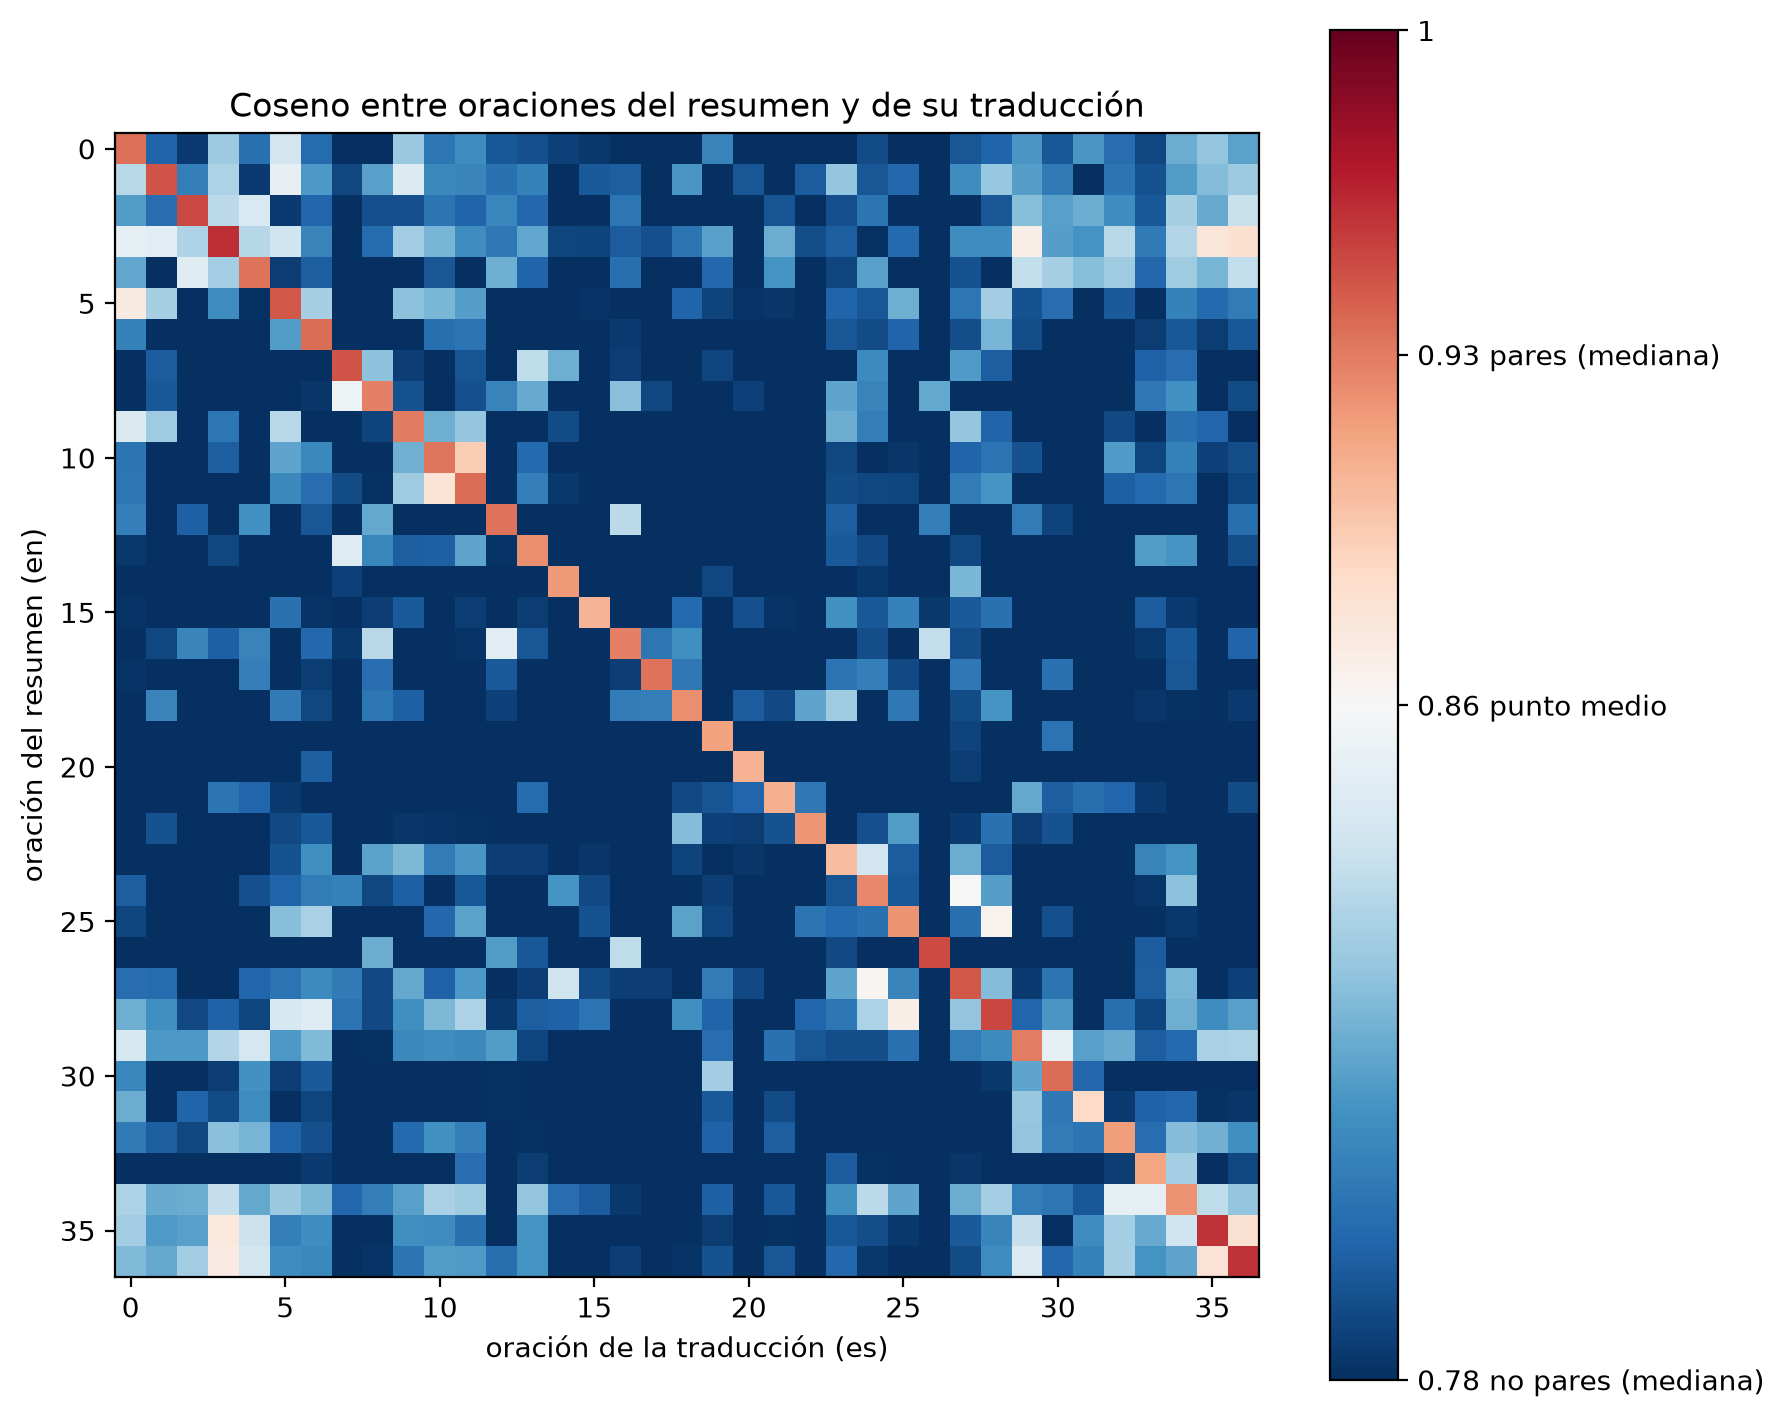

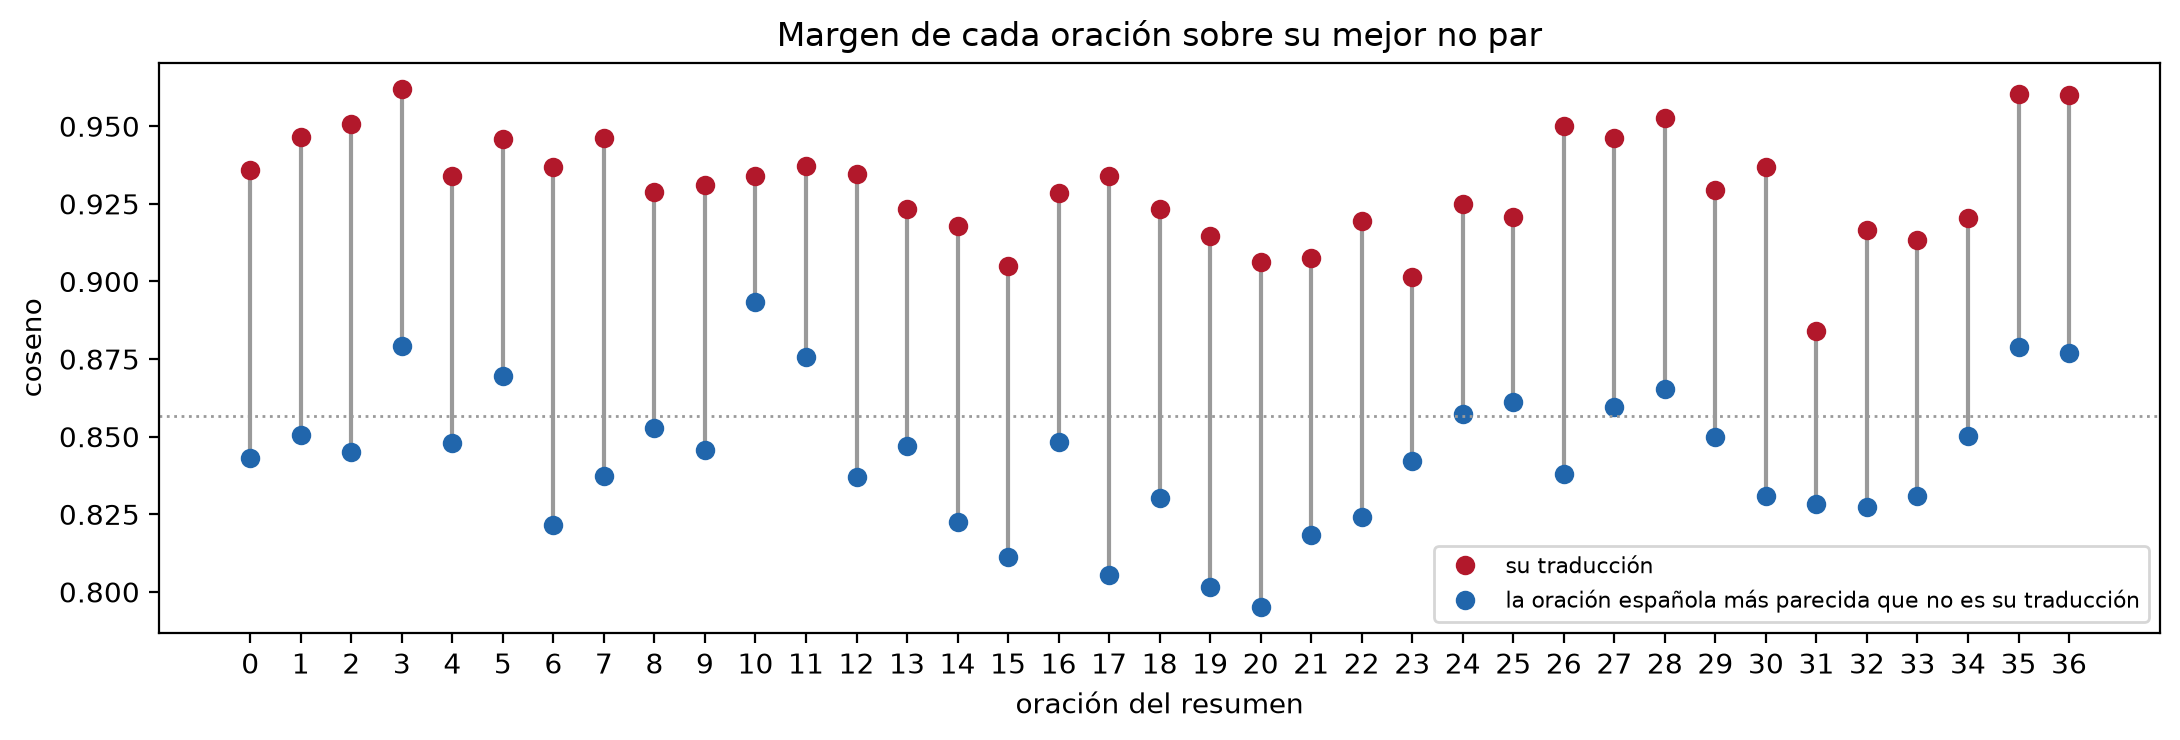

par más débil     : Science and scholarship had come of age. | La ciencia y la erudición habían llegado a la mayoría de edad.
margen más justo  : There are some hundred billion galaxies, each with, on the average, a hundred billion stars. | mejor no par: En todas las galaxias hay quizás tantos planetas como estrellas.


In [18]:
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

sim_en_es = E_sum @ E_trad.T
n = len(sim_en_es)
diagonal = np.diag(sim_en_es)
off_diagonal = sim_en_es[~np.eye(n, dtype=bool)]
masked = np.where(np.eye(n, dtype=bool), -1, sim_en_es)
best_non_pair, best_non_pair_index = masked.max(axis=1), masked.argmax(axis=1)
margin = diagonal - best_non_pair
row_argmax_is_pair = sim_en_es.argmax(axis=1) == np.arange(n)
print(f'oraciones inglesas cuya oración española más parecida es su propia traducción: {row_argmax_is_pair.sum()} de {n}')
print(f'coseno mediano entre pares {np.median(diagonal):.3f}; entre no pares {np.median(off_diagonal):.3f}; '
      f'par más débil {diagonal.min():.3f} (oración {diagonal.argmin()}); '
      f'margen más justo sobre el mejor no par {margin.min():.3f} (oración {margin.argmin()})')

midpoint = (np.median(diagonal) + np.median(off_diagonal)) / 2
fig, ax = plt.subplots(figsize=(9, 7.5), dpi=200)
im = ax.imshow(sim_en_es, cmap='RdBu_r', norm=TwoSlopeNorm(vmin=np.median(off_diagonal), vcenter=midpoint, vmax=1))
ax.set_xlabel('oración de la traducción (es)')
ax.set_ylabel('oración del resumen (en)')
ax.set_title('Coseno entre oraciones del resumen y de su traducción')
cbar = fig.colorbar(im, ax=ax)
cbar.set_ticks([np.median(off_diagonal), midpoint, np.median(diagonal), 1])
cbar.set_ticklabels([f'{np.median(off_diagonal):.2f} no pares (mediana)', f'{midpoint:.2f} punto medio', f'{np.median(diagonal):.2f} pares (mediana)', '1'])
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 3.8), dpi=200)
x = np.arange(n)
ax.vlines(x, best_non_pair, diagonal, color='#9a9a9a', linewidth=1.5)
ax.plot(x, diagonal, 'o', color='#b2182b', markersize=6, label='su traducción')
ax.plot(x, best_non_pair, 'o', color='#2166ac', markersize=6, label='la oración española más parecida que no es su traducción')
ax.axhline(midpoint, color='#9a9a9a', linestyle=':', linewidth=1)
ax.set_xticks(x)
ax.set_xlabel('oración del resumen')
ax.set_ylabel('coseno')
ax.set_title('Margen de cada oración sobre su mejor no par')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

print('par más débil     :', summary_sentences[diagonal.argmin()], '|', translation_sentences[diagonal.argmin()])
print('margen más justo  :', summary_sentences[margin.argmin()], '| mejor no par:', translation_sentences[best_non_pair_index[margin.argmin()]])



En el mapa, el rojo marca cosenos por encima del punto medio entre las dos medianas y el azul por debajo: rojo se lee como "misma idea", azul como "sin relación", y el blanco es la frontera. La diagonal es roja de punta a punta: las 37 oraciones encuentran como más parecida a su propia traducción. Pero hay celdas claras y hasta rosadas fuera de la diagonal, y no son errores del modelo: son oraciones distintas del resumen que hablan de lo mismo (galaxias, estrellas, el Cosmos) y se parecen entre idiomas casi tanto como un par de verdad. El segundo gráfico lo pone oración por oración: el punto rojo es el coseno con su traducción, el azul el mejor no par, y la línea es el margen. Ninguna se cruza. La más justa es la oración 10 ("cien mil millones de galaxias, cada una con cien mil millones de estrellas"), cuyo mejor no par es la oración vecina sobre planetas y estrellas: mismo vocabulario, otra idea, margen de 0.04.

Uso la mediana y no el promedio porque son 37 pares y uno raro no debería mover la lectura del grupo. El par más débil es una oración corta y abstracta ("Science and scholarship had come of age", 0.884), y su traducción es correcta.

Con esto tengo la vara para leer todo lo que sigue: **~0.93 es "la misma idea", ~0.78 es "sin relación"**, y una oración no relacionada puede llegar a 0.89 solo por compartir tema y vocabulario.


In [19]:
en_mentions = sorted(set(summary_entities[summary_entities.type.isin(kept_types)].mention))
es_mentions = sorted(set(translation_entities[translation_entities.type.isin(kept_types)].mention))
sim_mentions = embed(en_mentions) @ embed(es_mentions).T
entity_alignment = pd.DataFrame({
    'summary_en': en_mentions,
    'closest_in_translation': [es_mentions[i] for i in sim_mentions.argmax(axis=1)],
    'cosine': sim_mentions.max(axis=1).round(3),
    'runner_up': [es_mentions[i] for i in np.argsort(sim_mentions, axis=1)[:, -2]],
    'runner_up_cosine': np.sort(sim_mentions, axis=1)[:, -2].round(3),
})
entity_alignment['gap'] = (entity_alignment.cosine - entity_alignment.runner_up_cosine).round(3)
entity_alignment.sort_values('gap')


,summary_en,closest_in_translation,cosine,runner_up,runner_up_cosine,gap
0,Alexandria,galaxia,0.866,Alejandría,0.865,0.001
12,planet,tierra,0.881,Tierra,0.877,0.004
11,galaxy,galaxia,0.946,galaxias,0.932,0.014
3,Earth,Tierra,0.917,tierra,0.899,0.018
10,galaxies,galaxias,0.972,galaxia,0.954,0.018
9,earth,tierra,0.920,Tierra,0.901,0.019
7,Syene,Síene,0.932,Syean,0.904,0.028
14,universe,universo,0.934,galaxia,0.888,0.046
8,Worlds,mundos,0.936,mundo,0.887,0.049
15,world,mundo,0.948,mundos,0.897,0.051


Este cruce cierra lo que P2 dejó pendiente. Con el segundo candidato (`runner_up`) a más de 0.04 de distancia (`gap`), todos los emparejamientos son correctos. Por debajo de 0.02 hay aciertos (*Syene→Síene*, *galaxy→galaxia*) y el único fallo real: *Alexandria* cae en *galaxia* y no en *Alejandría*, por una milésima de coseno. *planet* cae en *tierra* porque en la lista española no hay ningún *planeta* con qué emparejarlo: es consecuencia de P2, no del embedding. Un vector de una sola palabra es una señal pobre (el modelo se entrenó para alinear oraciones, no nombres sueltos), y la columna `gap` muestra hasta dónde fiarse de él.


### Resumen contra capítulo

Ahora la pregunta central: ¿el resumen se parece al capítulo del que salió? Lo primero que quiero es un solo número: un vector del capítulo entero contra un vector del resumen entero. El capítulo no cabe en la ventana de 512 tokens de este modelo (la celda imprime cuántos tiene), así que el vector del capítulo es el promedio de los vectores de sus párrafos, renormalizado, y el del resumen el promedio de los de sus oraciones.

Ese número solo no se puede leer: hace falta saber qué coseno saca un texto que *no* es el capítulo pero se le parece en todo lo demás. Para eso uso **el capítulo II del mismo libro** ("One Voice in the Cosmic Fugue"), extraído con el mismo script: mismo autor, mismo tema, mismo estilo, otro contenido. Si el resumen se parece al capítulo I tanto como al II, el embedding está reconociendo "Sagan hablando del cosmos", no ese capítulo concreto.


In [20]:
chapter2_text = Path('data/chapter_02.txt').read_text(encoding='utf-8')
chapter2_paragraphs = [p for p in chapter2_text.split('\n\n') if p.strip()]
E_ch1, E_ch2 = embed(paragraphs), embed(chapter2_paragraphs)

def pooled(E):
    v = E.mean(axis=0)
    return v / np.linalg.norm(v)

v_ch1, v_ch2, v_sum, v_trad = pooled(E_ch1), pooled(E_ch2), pooled(E_sum), pooled(E_trad)
whole_document = pd.DataFrame({
    'vs_chapter_1': [v_sum @ v_ch1, v_trad @ v_ch1],
    'vs_chapter_2': [v_sum @ v_ch2, v_trad @ v_ch2],
}, index=['summary_en', 'translation_es'])
whole_document['margin'] = whole_document.vs_chapter_1 - whole_document.vs_chapter_2

print(f"capítulo I: {len(paragraphs)} párrafos, {len(embedder.tokenizer(text)['input_ids'])} tokens con el tokenizador de e5 (ventana {embedder.max_seq_length}); "
      f'capítulo II: {len(chapter2_paragraphs)} párrafos')
print(f'coseno entre los dos capítulos enteros: {v_ch1 @ v_ch2:.3f}')
whole_document.round(3)


capítulo I: 33 párrafos, 6447 tokens con el tokenizador de e5 (ventana 512); capítulo II: 51 párrafos
coseno entre los dos capítulos enteros: 0.974


,vs_chapter_1,vs_chapter_2,margin
summary_en,0.958,0.946,0.012
translation_es,0.941,0.929,0.012


El número que quería resulta inservible, y la línea base es lo que lo muestra. El resumen contra su capítulo da 0.958; contra el capítulo II, 0.946: una diferencia de 0.012, cuando la vara de arriba dice que entre "misma idea" y "sin relación" hay 0.15. Y los dos capítulos enteros, que no son resumen de nada, se parecen entre sí más (0.974) de lo que el resumen se parece a su propia fuente. Promediar los vectores de 33 párrafos borra lo que distingue a un capítulo de otro y deja solo lo que comparten: Sagan hablando del cosmos. Sin el capítulo II al lado habría escrito "el resumen conserva el 96% del capítulo" y habría sido falso.

Así que la comparación tiene que bajar de nivel: oración del resumen contra párrafo del capítulo, que es la unidad más grande que cabe entera en la ventana. Y parto de una intuición: que el resumen se arma citando de cerca ciertos párrafos, y que un párrafo al que ninguna oración del resumen se acerca es un párrafo que el resumen ignoró. Si eso es verdad, los párrafos sin oración deberían ser los que perdieron nombres en P2.


In [21]:
sim_sum_ch1 = E_sum @ E_ch1.T
sim_sum_ch2 = E_sum @ E_ch2.T
sentence_match = pd.DataFrame({
    'best_ch1': sim_sum_ch1.max(axis=1).round(3),
    'best_ch1_paragraph': sim_sum_ch1.argmax(axis=1),
    'best_ch2': sim_sum_ch2.max(axis=1).round(3),
    'sentence': [s[:70] + '…' for s in summary_sentences],
})
sentence_match['margin'] = (sentence_match.best_ch1 - sentence_match.best_ch2).round(3)
print(f"oraciones del resumen más cercanas a un párrafo del capítulo I que a uno del II: {(sentence_match.margin > 0).sum()} de {len(sentence_match)}; "
      f"margen mediano {sentence_match.margin.median():.3f}; "
      f"coseno mediano con el mejor párrafo del I {sentence_match.best_ch1.median():.3f}, del II {sentence_match.best_ch2.median():.3f}")

sentences_per_paragraph, offset = [], 0
for p in paragraphs:
    n_sentences = len([s for s in SENTENCE.split(p) if s.strip()])
    sentences_per_paragraph.append(range(offset, offset + n_sentences))
    offset += n_sentences

lost_keys = {t: chapter_keys[t] - summary_keys[t] for t in kept_types}

def has_lost_entity(sentence_range):
    rows = chapter_entities[chapter_entities.sentence.isin(sentence_range)]
    return any(bool(set(rows[rows.type == t].key) & lost_keys[t]) for t in kept_types)

pointed_by = pd.Series(sentence_match.best_ch1_paragraph).value_counts()
paragraph_coverage = pd.DataFrame({
    'words': paragraph_table.words,
    'summary_sentences_pointing_here': pointed_by.reindex(range(len(paragraphs))).fillna(0).astype(int),
    'best_summary_sentence': sim_sum_ch1.max(axis=0).round(3),
    'has_lost_entity': [has_lost_entity(r) for r in sentences_per_paragraph],
    'start': paragraph_table.start,
})
uncovered = paragraph_coverage.summary_sentences_pointing_here == 0
print(f"párrafos a los que apunta al menos una oración del resumen: {(~uncovered).sum()} de {len(paragraphs)}; "
      f"los {uncovered.sum()} restantes suman {paragraph_coverage.words[uncovered].sum()} de {paragraph_coverage.words.sum()} palabras")
print(pd.crosstab(uncovered, paragraph_coverage.has_lost_entity, rownames=['no_sentence_points_here'], colnames=['has_lost_entity']))
paragraph_coverage.sort_values(['summary_sentences_pointing_here', 'best_summary_sentence'])


oraciones del resumen más cercanas a un párrafo del capítulo I que a uno del II: 35 de 37; margen mediano 0.027; coseno mediano con el mejor párrafo del I 0.839, del II 0.811
párrafos a los que apunta al menos una oración del resumen: 14 de 33; los 19 restantes suman 2486 de 4459 palabras
has_lost_entity          False  True 
no_sentence_points_here              
False                        7      7
True                         3     16


,words,summary_sentences_pointing_here,best_summary_sentence,has_lost_entity,start
27,132,0,0.815,True,The city was founded by Alexander the Great and constructed …
24,119,0,0.821,True,Columbus had been an itinerant peddler of old maps and an as…
22,183,0,0.826,True,"In Eratosthenes’ time, globes were constructed portraying th…"
23,120,0,0.828,True,The subsequent exploration of the Earth was a worldwide ende…
12,70,0,0.829,False,"We have now reached our own backyard, a light-year from Eart…"
26,107,0,0.835,True,"It was in Alexandria, during the six hundred years beginning…"
11,104,0,0.836,True,Some stars may be surrounded by millions of lifeless and roc…
16,214,0,0.838,True,"The discovery that the Earth is a little world was made, as …"
7,113,0,0.839,True,But presently our journey takes us to what astronomers on Ea…
30,219,0,0.839,True,The heart of the library was its collection of books. The or…


Con la vara de EN/ES, 0.839 contra 0.811 sigue lejos de "misma idea": casi todas las oraciones del resumen tienen un párrafo del capítulo I un poco más cercano que el mejor del II, pero por un margen mediano de 0.027. El capítulo propio gana casi siempre, por poco.

La cobertura sí dice algo, porque no depende del valor absoluto: 14 de los 33 párrafos reciben alguna oración; los 19 restantes suman más de la mitad de las palabras del capítulo. Y el cruce con P2 va en la dirección que esperaba: 16 de los 19 párrafos sin oración perdieron algún nombre, contra 7 de los 14 con oración. Los que más pesan son los del recorrido cósmico (M31, la Vía Láctea, los planetas): no reciben ninguna oración y perdieron todos sus astros.

Pero la intuición se sostiene solo a medias. Que un párrafo no reciba oración no prueba que el resumen lo ignore: sus ideas pueden estar repetidas en otro párrafo con mejor coseno. El resumen no funciona como un extracto de oraciones top por párrafo; generaliza, y por momentos no se pega a ningún párrafo concreto. Y la cobertura es sobre 33 párrafos, de los que 23 perdieron algún nombre: 16 de 19 contra 7 de 14 es una diferencia, no una prueba.


In [22]:
rng = np.random.default_rng(0)

def shuffle_words(passage):
    words = passage.split()
    rng.shuffle(words)
    return ' '.join(words)

E_shuffled = embed([shuffle_words(p) for p in paragraphs])
self_similarity = (E_ch1 * E_shuffled).sum(axis=1)
print(f'coseno entre cada párrafo y su versión con las palabras barajadas: mediana {np.median(self_similarity):.3f}, '
      f'mínimo {self_similarity.min():.3f}, máximo {self_similarity.max():.3f}')

references = pd.Series({
    'oración vs su traducción (misma idea, otro idioma)': np.median(diagonal),
    'párrafo vs sus palabras barajadas (mismo vocabulario, sin sintaxis)': np.median(self_similarity),
    'párrafos distintos del capítulo I (mismo autor y tema)': np.median((E_ch1 @ E_ch1.T)[np.triu_indices(len(paragraphs), k=1)]),
    'oraciones no pareadas del resumen y la traducción (sin relación)': np.median(off_diagonal),
}, name='median_cosine').round(3)
references.to_frame()


coseno entre cada párrafo y su versión con las palabras barajadas: mediana 0.933, mínimo 0.913, máximo 0.965


,median_cosine
"oración vs su traducción (misma idea, otro idioma)",0.931
"párrafo vs sus palabras barajadas (mismo vocabulario, sin sintaxis)",0.933
párrafos distintos del capítulo I (mismo autor y tema),0.846
oraciones no pareadas del resumen y la traducción (sin relación),0.782


Un párrafo con las palabras barajadas (mismo vocabulario, ninguna sintaxis, ningún sentido) se parece a su original tanto como una traducción fiel se parece a su fuente, y más que dos párrafos distintos del mismo capítulo. El coseno de este modelo mide sobre todo qué palabras comparten dos textos, no qué dicen. Eso explica los dos resultados anteriores: dos capítulos de Sagan sobre el cosmos comparten casi todo el vocabulario, y por eso el capítulo II saca casi lo mismo que el I, tanto entero como por párrafos.

**Cierre de P3.** Las pruebas limpias son las que tienen par conocido: resumen contra traducción, y el cruce de nombres. Resumen contra capítulo, entero o por párrafos, dice menos de lo que parece, y la tabla de referencias dice por qué. Lo que sí queda en pie es la cobertura leída junto con P2: los párrafos sin oración concentran los nombres perdidos, sobre todo los astros.


## Respuestas

**¿Qué queda del capítulo al resumirlo?** Con un modelo entrenado con noticias, nada utilizable: titulares con fechas y países inventados. Con un modelo entrenado con libros, un resumen que sigue el orden del capítulo, conserva una sola escena con sus nombres (Eratóstenes midiendo la Tierra en Alejandría) y reduce el resto a ideas generales; más de la mitad de las palabras del capítulo no son la fuente cercana de ninguna oración del resumen. Y contiene dos errores plausibles (una cita atribuida a quien no la dijo, una fecha imposible) que ninguna herramienta de la cadena detecta.

**¿Qué entidades desaparecen?** Las que no pertenecen a esa escena: los demás sabios de Alejandría, Colón y Magallanes, los continentes y océanos, y todos los astros con nombre propio. Lo único que el resumen trae y el capítulo no es *Syean*, una deformación de *Syene*.

**¿Qué tan fiel es la traducción?** Fiel oración por oración: cada una es la más parecida a su original y ninguna se confunde con otra, ni siquiera entre oraciones que comparten vocabulario. Su defecto es alisar: la fecha imposible del inglés salió como una fecha normal en español.

**¿Qué tan cerca están resumen y capítulo?** Con esta métrica la pregunta está mal planteada: el coseno mide vocabulario compartido, y un capítulo ajeno del mismo autor saca casi lo mismo que el propio, entero o por párrafos. Lo que sirve es a qué párrafo apunta cada oración, cruzado con las entidades perdidas de P2.

## Conclusiones

1. **El dominio de entrenamiento pesa más que la arquitectura.** El primer resumidor falló por haber aprendido que un resumen es la primera frase de una noticia, no por su tamaño. Antes de elegir un modelo hay que leer con qué datos se ajustó.
2. **Un resumen puede ser fiel y engañoso a la vez.** El de LED no inventa lugares ni fechas de la nada, y aun así su lector creería que Eratóstenes dijo una frase que no dijo. Los errores plausibles son los peligrosos, y son los que esta cadena no ve.
3. **Encadenar modelos sirve cuando cada uno mide algo distinto.** Sin el traductor no habría podido leer el resumen; sin el modelo de entidades habría creído que cubrir un párrafo era conservarlo; sin la línea base habría vendido un 0.96.
4. **Sin referencia, un coseno es una opinión.** Y la referencia hay que fabricarla con pares de los que se sabe la respuesta (una traducción, un texto barajado, un capítulo ajeno), no leerla del número.
5. **Un traductor alisa.** Está entrenado para producir texto fluido y lo produce también a partir de una entrada rota. Sirve para leer; no sirve para auditar.
6. Lo que seguiría: repetir con varios capítulos para que las cifras sean distribuciones; comparar el mismo capítulo con un resumidor de noticias en inglés (BART-CNN) para aislar el efecto del dominio sin cambiar de idioma; y usar un modelo de pregunta-respuesta para verificar afirmaciones concretas del resumen contra la fuente, que es la única forma automática de atrapar una atribución falsa.


## Tareas de Hugging Face usadas

| Tarea del Hub | Modelo | Cómo se carga | Dónde |
|---|---|---|---|
| `summarization` | `csebuetnlp/mT5_multilingual_XLSum` (intento 1, descartado) y `pszemraj/led-large-book-summary` | `pipeline('summarization')` | P1 |
| `translation` | `Helsinki-NLP/opus-mt-en-es` | `pipeline('translation')` | P1 |
| `token-classification` (NER) | `tomaarsen/span-marker-mbert-base-multinerd` | `SpanMarkerModel.from_pretrained` (librería `span_marker`, sobre `transformers`) | P2 |
| `sentence-similarity` | `intfloat/multilingual-e5-base` | `SentenceTransformer` (librería `sentence-transformers`) | P3 |

Ninguna de las cuatro tareas ni de los modelos coincide con lo visto en clase (análisis de sentimiento, clasificación de texto, *fill-mask* y generación con GPT-2). Todo corre en local con `transformers 4.57`; la versión 5 eliminó los pipelines de resumen y traducción, y por eso la primera celda fija la versión.
